In [45]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import matplotlib.pyplot as plt

In [46]:
df = pd.read_csv("/Users/manojmj/PycharmProjects/machinelearning subject/expno8/dataset/Groceries_dataset.csv")
df['Transaction'] = df['Member_number'].astype(str) + "_" + df['Date'].astype(str)

In [47]:
transactions = df.groupby('Transaction')['itemDescription'].apply(list).tolist()

print("Total Transactions:", len(transactions))
print("Sample Transaction:", transactions[0])

Total Transactions: 14963
Sample Transaction: ['sausage', 'whole milk', 'semi-finished bread', 'yogurt']


In [48]:
te = TransactionEncoder()
te_data = te.fit(transactions).transform(transactions)

df_encoded = pd.DataFrame(te_data, columns=te.columns_)

print(df_encoded.shape)
df_encoded.head()

(14963, 167)


,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [49]:
freq_items = apriori(df_encoded, min_support=0.005, use_colnames=True)

print("Frequent Itemsets:", len(freq_items))
freq_items.head()

Frequent Itemsets: 126


,support,itemsets
0,0.021386,frozenset({UHT-milk})
1,0.008087,frozenset({baking powder})
2,0.033950,frozenset({beef})
3,0.021787,frozenset({berries})
4,0.016574,frozenset({beverages})


In [50]:
rules = association_rules(freq_items, metric="confidence", min_threshold=0.005)

# Filter strong rules
rules = rules[rules['lift'] > 1]

print("Total Rules:", len(rules))
rules[['antecedents','consequents','support','confidence','lift']].head()

Total Rules: 6


,antecedents,consequents,support,confidence,lift
12,frozenset({other vegetables}),frozenset({frankfurter}),0.005146,0.042146,1.116150
13,frozenset({frankfurter}),frozenset({other vegetables}),0.005146,0.136283,1.116150
54,frozenset({soda}),frozenset({sausage}),0.005948,0.061253,1.014975
55,frozenset({sausage}),frozenset({soda}),0.005948,0.098560,1.014975
58,frozenset({yogurt}),frozenset({sausage}),0.005748,0.066926,1.108986


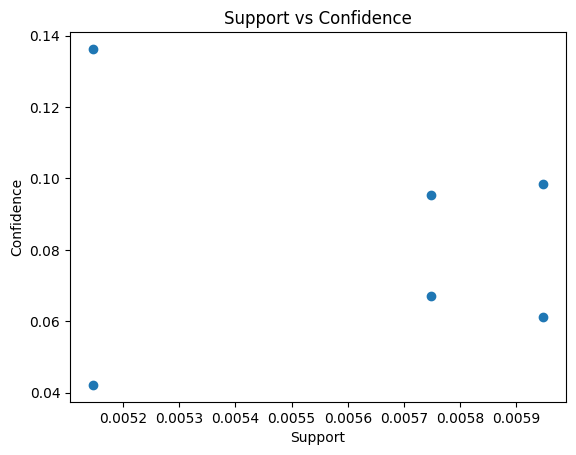

In [51]:
plt.figure()
plt.scatter(rules['support'], rules['confidence'])
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Support vs Confidence")
plt.show()

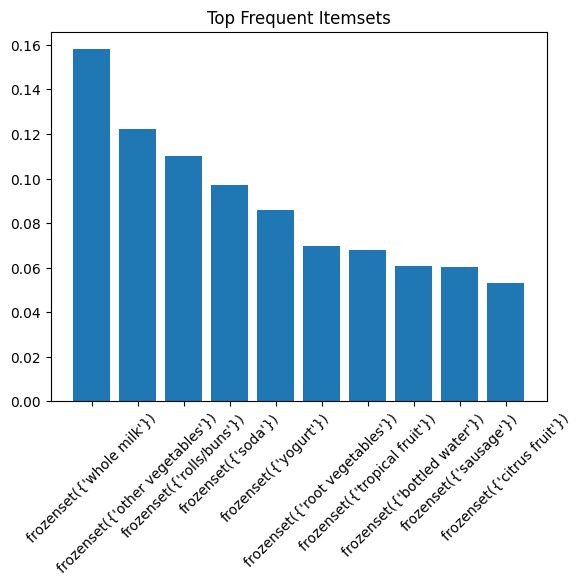

In [52]:
top_items = freq_items.sort_values(by='support', ascending=False).head(10)

plt.figure()
plt.bar(range(len(top_items)), top_items['support'])
plt.xticks(range(len(top_items)), top_items['itemsets'], rotation=45)
plt.title("Top Frequent Itemsets")
plt.show()